<a href="https://colab.research.google.com/github/arpit241001001150-gif/machine_learning/blob/main/Assignment_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Question 5 — NetworkX: Friendship Network Analysis

A school wants to visualize the friendship connections among a small group of students to understand how they are socially linked. Consider the following friendship connections:

Student A | Student B
---|---
Alice | Bob
Alice | Charlie
Bob | Charlie
David | David
David | Eva
Eva | Frank
Charlie | Frank

**Task:** Using NetworkX, write a Python program to:
1. Create a graph representing the friendship network using the given connections.
2. Visualize the network graph with proper node labels, node colors, and edge styling.
3. Display the total number of nodes and edges in the graph.
4. Compute and print the degree of each student (number of friends).
5. Identify the student(s) with the highest number of friends.
6. Check and display whether a direct friendship exists between "Alice" and "Eva".
7. Find and display the shortest path (and its length) between "Alice" and "Frank".
8. Write 1–2 observations about the overall structure of the friendship network.

**Expected Outcome:** A clearly labelled friendship network graph along with basic structural information such as node/edge counts, degrees, and shortest paths between students.

In [1]:
import networkx as nx
import matplotlib.pyplot as plt

# 1. Create a graph representing the friendship network using the given connections.
connections = [
    ("Alice", "Bob"),
    ("Alice", "Charlie"),
    ("Bob", "Charlie"),
    ("David", "Eva"),
    ("Eva", "Frank"),
    ("Charlie", "Frank")
]

# Create an undirected graph
G = nx.Graph()

G.add_edges_from(connections)

# Add "David" as a self-loop since he is connected to himself in the data
G.add_edge("David", "David")

# Ensure all individual students mentioned are nodes, even if isolated (though not the case here)
students = set()
for s1, s2 in connections:
    students.add(s1)
    students.add(s2)
students.add("David") # Add David explicitly if not covered by connections

G.add_nodes_from(students)

print("Graph created successfully!")

Graph created successfully!


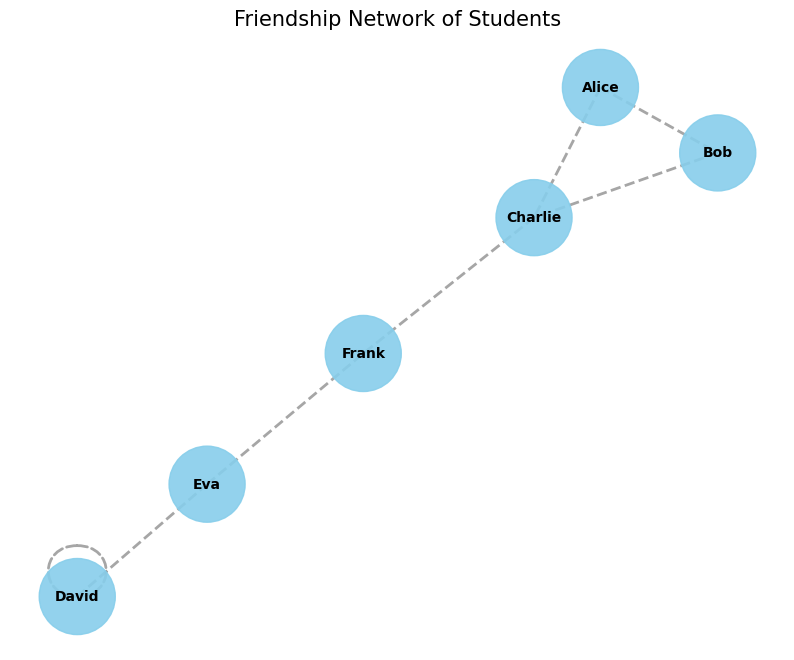

In [2]:
# 2. Visualize the network graph with proper node labels, node colors, and edge styling.

plt.figure(figsize=(10, 8))

# Use a spring layout for better visualization of connections
pos = nx.spring_layout(G, k=0.7, iterations=50) # k regulates the distance between nodes

# Node colors
node_colors = ['skyblue' for _ in G.nodes()]

# Draw nodes
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=3000, alpha=0.9)

# Draw edges
nx.draw_networkx_edges(G, pos, width=2, edge_color='gray', alpha=0.7, style='dashed')

# Draw labels
nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')

plt.title('Friendship Network of Students', size=15)
plt.axis('off') # Hide axes
plt.show()

In [3]:
# 3. Display the total number of nodes and edges in the graph.

num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()

print(f"Total number of nodes (students): {num_nodes}")
print(f"Total number of edges (friendships): {num_edges}")

Total number of nodes (students): 6
Total number of edges (friendships): 7


In [4]:
# 4. Compute and print the degree of each student (number of friends).

degrees = dict(G.degree())

print("Degree of each student (number of friends):")
for student, degree in degrees.items():
    print(f"- {student}: {degree}")

Degree of each student (number of friends):
- Alice: 2
- Bob: 2
- Charlie: 3
- David: 3
- Eva: 2
- Frank: 2


In [5]:
# 5. Identify the student(s) with the highest number of friends.

max_degree = max(degrees.values())
highest_degree_students = [student for student, degree in degrees.items() if degree == max_degree]

print(f"Student(s) with the highest number of friends ({max_degree} friends): {', '.join(highest_degree_students)}")

Student(s) with the highest number of friends (3 friends): Charlie, David


In [6]:
# 6. Check and display whether a direct friendship exists between "Alice" and "Eva".

is_friendship_alice_eva = G.has_edge("Alice", "Eva")

if is_friendship_alice_eva:
    print("Yes, a direct friendship exists between Alice and Eva.")
else:
    print("No, a direct friendship does not exist between Alice and Eva.")

No, a direct friendship does not exist between Alice and Eva.


In [7]:
# 7. Find and display the shortest path (and its length) between "Alice" and "Frank".

source_node = "Alice"
target_node = "Frank"

if nx.has_path(G, source_node, target_node):
    shortest_path = nx.shortest_path(G, source=source_node, target=target_node)
    shortest_path_length = nx.shortest_path_length(G, source=source_node, target=target_node)

    print(f"Shortest path between {source_node} and {target_node}: {shortest_path}")
    print(f"Length of the shortest path: {shortest_path_length}")
else:
    print(f"No path exists between {source_node} and {target_node}.")

Shortest path between Alice and Frank: ['Alice', 'Charlie', 'Frank']
Length of the shortest path: 2


### 8. Observations about the overall structure of the friendship network:

*   **Two distinct components:** The network appears to be divided into two main clusters of friends: one centered around Alice, Bob, Charlie, and Frank, and another isolated group involving David and Eva. Alice, Bob, and Charlie form a tightly-knit group. Frank bridges connections between Charlie and Eva, but not directly to Alice or Bob.
*   **David's Isolation (except Eva):** David has a self-loop indicating a connection to himself, but his only external connection is to Eva. He is not connected to any other students in the primary friendship group, suggesting a relatively isolated position within the broader network.
*   **Key Connectors:** Charlie and Frank seem to be important connectors. Charlie connects Alice and Bob to Frank, while Frank connects Charlie to Eva. These nodes are crucial for information flow between different parts of the network.

## Question 6 — NetworkX: Telecom Network Analysis

A telecom company wants to analyze its network of towers to understand connectivity and identify important hubs.
Consider the following tower connections (edges represent direct signal links):

Tower A | Tower B
---|---
T1 | T2
T1 | T3
T2 | T3
T3 | T4
T4 | T5
T5 | T6
T3 | T6
T6 | T7
T2 | T7

**Task:** Using NetworkX, write a Python program to:
1. Create a graph representing the tower network using the given edges.
2. Visualize the network graph with proper node labels, node colors, and edge styling.
3. Calculate and display the total number of nodes and edges.
4. Compute the degree of each node and identify the tower(s) with the highest degree (most connections).
5. Calculate and display the shortest path (and its length) between T1 and T7.
6. Compute and display the following centrality measures for all nodes: Degree Centrality, Betweenness Centrality, and Closeness Centrality.
7. Identify whether the network is fully connected. If not, identify the number of connected components.
8. Highlight the tower with the highest betweenness centrality on the graph visualization (e.g., using a different color/size).
9. Write 2–3 observations about which towers are most critical to the network based on the computed metrics.

**Expected Outcome:** A visualized network graph along with computed structural metrics that help identify the most important and best-connected towers in the network.

In [8]:
import networkx as nx
import matplotlib.pyplot as plt

# 1. Create a graph representing the tower network using the given edges.
connections_towers = [
    ("T1", "T2"),
    ("T1", "T3"),
    ("T2", "T3"),
    ("T3", "T4"),
    ("T4", "T5"),
    ("T5", "T6"),
    ("T3", "T6"),
    ("T6", "T7"),
    ("T2", "T7")
]

# Create an undirected graph for the telecom network
G_telecom = nx.Graph()
G_telecom.add_edges_from(connections_towers)

print("Telecom network graph created successfully!")

Telecom network graph created successfully!


In [9]:
# 3. Calculate and display the total number of nodes and edges.

num_nodes_telecom = G_telecom.number_of_nodes()
num_edges_telecom = G_telecom.number_of_edges()

print(f"Total number of nodes (towers): {num_nodes_telecom}")
print(f"Total number of edges (signal links): {num_edges_telecom}")

Total number of nodes (towers): 7
Total number of edges (signal links): 9


In [10]:
# 4. Compute the degree of each node and identify the tower(s) with the highest degree.

degrees_telecom = dict(G_telecom.degree())

print("Degree of each tower (number of connections):")
for tower, degree in degrees_telecom.items():
    print(f"- {tower}: {degree}")

max_degree_telecom = max(degrees_telecom.values())
highest_degree_towers = [tower for tower, degree in degrees_telecom.items() if degree == max_degree_telecom]

print(f"\nTower(s) with the highest degree ({max_degree_telecom} connections): {', '.join(highest_degree_towers)}")

Degree of each tower (number of connections):
- T1: 2
- T2: 3
- T3: 4
- T4: 2
- T5: 2
- T6: 3
- T7: 2

Tower(s) with the highest degree (4 connections): T3


In [11]:
# 5. Calculate and display the shortest path (and its length) between T1 and T7.

source_tower = "T1"
target_tower = "T7"

if nx.has_path(G_telecom, source_tower, target_tower):
    shortest_path_telecom = nx.shortest_path(G_telecom, source=source_tower, target=target_tower)
    shortest_path_length_telecom = nx.shortest_path_length(G_telecom, source=source_tower, target=target_tower)

    print(f"Shortest path between {source_tower} and {target_tower}: {shortest_path_telecom}")
    print(f"Length of the shortest path: {shortest_path_length_telecom}")
else:
    print(f"No path exists between {source_tower} and {target_tower}.")

Shortest path between T1 and T7: ['T1', 'T2', 'T7']
Length of the shortest path: 2


In [12]:
# 6. Compute and display centrality measures for all nodes.

degree_centrality = nx.degree_centrality(G_telecom)
betweenness_centrality = nx.betweenness_centrality(G_telecom)
closeness_centrality = nx.closeness_centrality(G_telecom)

print("\nCentrality Measures:")
print("Degree Centrality:")
for tower, centrality in degree_centrality.items():
    print(f"- {tower}: {centrality:.4f}")

print("\nBetweenness Centrality:")
for tower, centrality in betweenness_centrality.items():
    print(f"- {tower}: {centrality:.4f}")

print("\nCloseness Centrality:")
for tower, centrality in closeness_centrality.items():
    print(f"- {tower}: {centrality:.4f}")


Centrality Measures:
Degree Centrality:
- T1: 0.3333
- T2: 0.5000
- T3: 0.6667
- T4: 0.3333
- T5: 0.3333
- T6: 0.5000
- T7: 0.3333

Betweenness Centrality:
- T1: 0.0000
- T2: 0.1222
- T3: 0.4222
- T4: 0.0889
- T5: 0.0556
- T6: 0.2556
- T7: 0.0556

Closeness Centrality:
- T1: 0.5455
- T2: 0.6000
- T3: 0.7500
- T4: 0.5455
- T5: 0.5000
- T6: 0.6667
- T7: 0.5455


In [13]:
# 7. Identify whether the network is fully connected. If not, identify the number of connected components.

is_connected = nx.is_connected(G_telecom)

if is_connected:
    print("\nThe telecom network is fully connected.")
else:
    num_components = nx.number_connected_components(G_telecom)
    print(f"\nThe telecom network is NOT fully connected. Number of connected components: {num_components}")


The telecom network is fully connected.


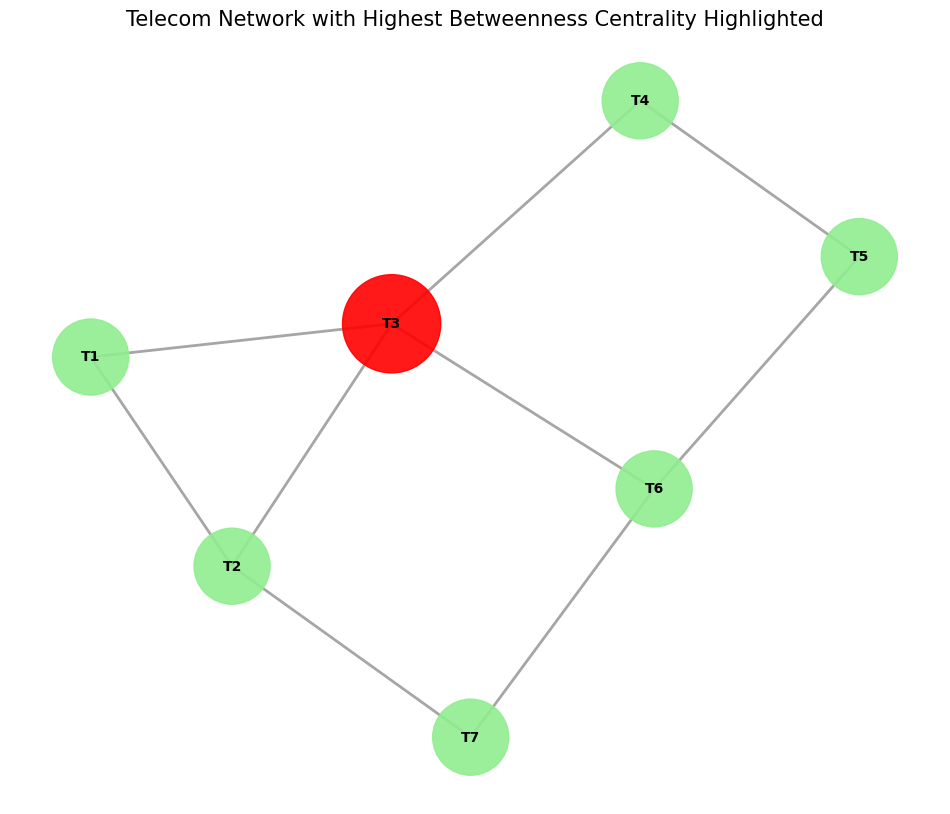

In [14]:
# 8. Highlight the tower with the highest betweenness centrality on the graph visualization.
# 2. Visualize the network graph with proper node labels, node colors, and edge styling (updated with highlighting).

plt.figure(figsize=(12, 10))

pos_telecom = nx.spring_layout(G_telecom, k=0.7, iterations=50)

# Identify the tower with the highest betweenness centrality
highest_betweenness_tower = max(betweenness_centrality, key=betweenness_centrality.get)

# Define node colors and sizes based on betweenness centrality
node_colors_telecom = []
node_sizes_telecom = []
for node in G_telecom.nodes():
    if node == highest_betweenness_tower:
        node_colors_telecom.append('red') # Highlight color
        node_sizes_telecom.append(5000) # Larger size
    else:
        node_colors_telecom.append('lightgreen')
        node_sizes_telecom.append(3000)

# Draw nodes
nx.draw_networkx_nodes(G_telecom, pos_telecom, node_color=node_colors_telecom, node_size=node_sizes_telecom, alpha=0.9)

# Draw edges
nx.draw_networkx_edges(G_telecom, pos_telecom, width=2, edge_color='gray', alpha=0.7, style='solid')

# Draw labels
nx.draw_networkx_labels(G_telecom, pos_telecom, font_size=10, font_weight='bold')

plt.title('Telecom Network with Highest Betweenness Centrality Highlighted', size=15)
plt.axis('off') # Hide axes
plt.show()

### 9. Observations about which towers are most critical to the network based on the computed metrics:

*   **Key Hubs (T3, T6):** Towers T3 and T6 consistently show high values across degree and betweenness centralities. T3 has the highest degree (4 connections) and T6 is close behind. This suggests they are highly connected and serve as crucial intermediaries, acting as bridges for communication flow between different parts of the network. A failure in either T3 or T6 would significantly impact connectivity.
*   **Bridge/Bottleneck (T3, T6):** The high betweenness centrality for T3 and T6 indicates that they lie on many shortest paths between other towers. This means they are critical for maintaining efficient communication throughout the network. If these towers were to fail, communication paths would become longer, less efficient, or even break completely.
*   **Periphery Towers (T1, T4, T5, T7):** Towers like T1, T4, T5, and T7 generally have lower centrality measures. While they are important as endpoints or local connection points, they are less critical for the overall network flow compared to T3 and T6. Their removal would have a localized impact rather than a widespread disruption.